In [5]:
%pip install pillow pytest


879.59s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Note: you may need to restart the kernel to use updated packages.


In [1]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import os
import random
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from torchvision import transforms
from torchvision.transforms import ToTensor
from PIL import Image as PILImage
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.transforms import ToTensor
from PIL import Image as PILImage
import torch.nn as nn
import torch.optim as optim
import numpy as np
import os

In [5]:
IMG_SIZE = 64 
NUM_CLASSES = 3 
def generate_shape():
    image=Image.new('RGB', (IMG_SIZE, IMG_SIZE), (255, 255, 255))
    draw=ImageDraw.Draw(image)
    shape_type=random.randint(0,2)
    x1=random.randint(5,30)
    y1=random.randint(5,30)
    x2=random.randint(30,60)
    y2=random.randint(30,60)
    if shape_type==0:
        draw.rectangle((x1,y1,x2,y2), fill=(255,0,0))
        label=0
    elif shape_type==1:
        draw.ellipse((x1,y1,x2,y2), fill=(0,255,0))
        label=1
    else:
        draw.polygon([(x1,y1),(x2,y1),(x2,y2)], fill=(0,0,255))
        label=2
    return image,label

In [6]:
images=[]
labels=[]
for _ in range(3000):
    img,label=generate_shape()
    img=np.array(img)/255.0 
    images.append(img)
    labels.append(label)
images=np.array(images, dtype=np.float32)
labels=np.array(labels, dtype=np.int64)

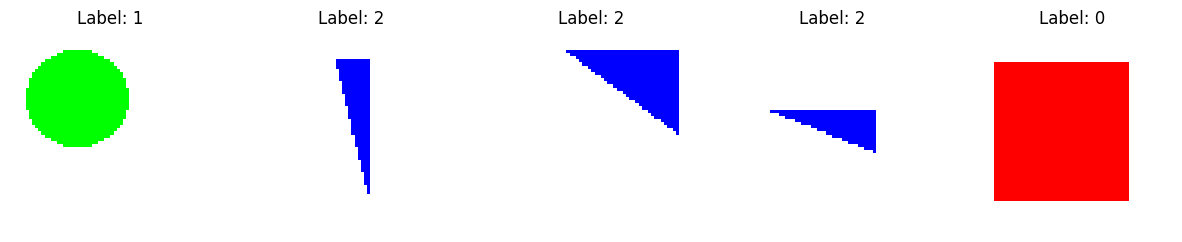

In [8]:
fig,axs=plt.subplots(1,5, figsize=(15,3))
for i in range(5):
    axs[i].imshow(images[i])
    axs[i].set_title(f'Label: {labels[i]}')
    axs[i].axis('off')
plt.show()

custom dataset class 

In [9]:
class ShapeDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)
train_dataset = ShapeDataset(X_train, y_train, transform=ToTensor())
test_dataset = ShapeDataset(X_test, y_test, transform=ToTensor())
print(f'Train samples: {len(train_dataset)}, Test samples: {len(test_dataset)}')

Train samples: 2400, Test samples: 600


In [14]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [15]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 16 * 16, 128)
        self.fc2 = nn.Linear(128, NUM_CLASSES)
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 32 * 16 * 16)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [16]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [17]:
epochs = 10
for epoch in range(epochs):
    running_loss=0.0 
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f'Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}')

Epoch 1/10, Loss: 0.1891
Epoch 2/10, Loss: 0.0020
Epoch 3/10, Loss: 0.0010
Epoch 4/10, Loss: 0.0004
Epoch 5/10, Loss: 0.0003
Epoch 6/10, Loss: 0.0003
Epoch 7/10, Loss: 0.0002
Epoch 8/10, Loss: 0.0001
Epoch 9/10, Loss: 0.0001
Epoch 10/10, Loss: 0.0001


In [18]:
correct=0 
total=0 
with torch.no_grad():
    for images,labels in test_loader:
        images,labels=images.to(device),labels.to(device)
        outputs=model(images)
        _,pred=torch.max(outputs,1)
        total+=labels.size(0)
        correct+=(pred==labels).sum().item()
print(f'Test Accuracy: {100*correct/total:.2f}%')

Test Accuracy: 100.00%
